✅ Data Loaded Successfully!
Total Records: 292
Recovered Cases for Analysis: 24



/tmp/ipython-input-3679424435.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='viridis')


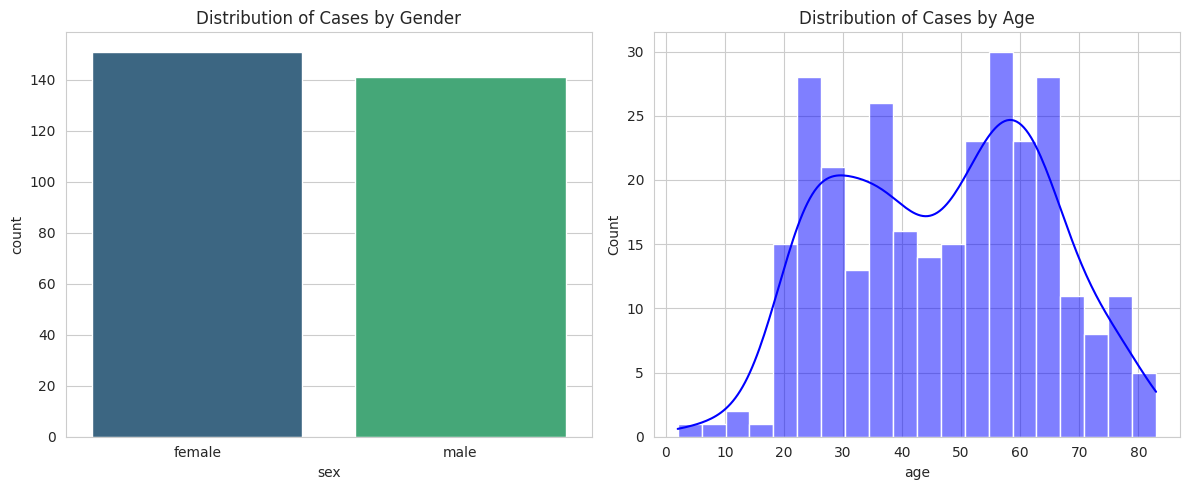

/tmp/ipython-input-3679424435.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='infection_reason', data=df[df['infection_reason'].isin(top_reasons)],


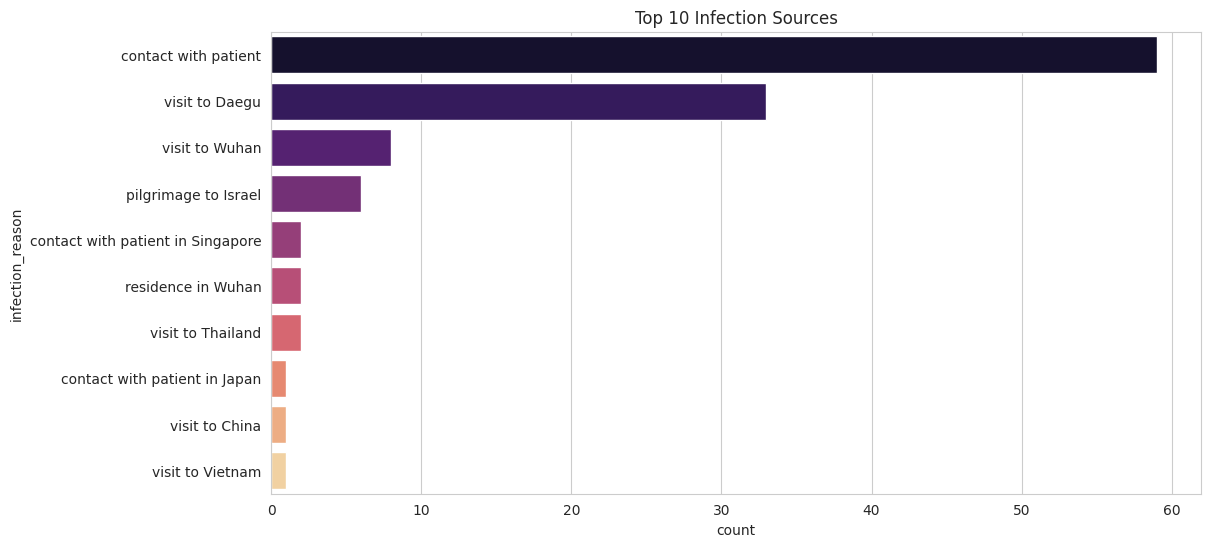

/tmp/ipython-input-3679424435.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='region', data=df[df['region'].isin(top_regions)],


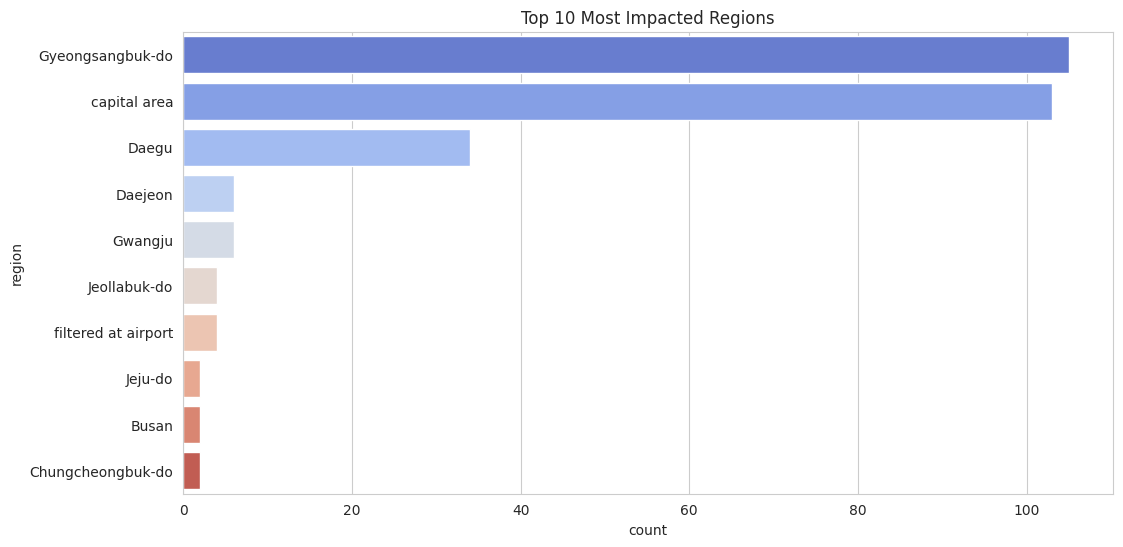

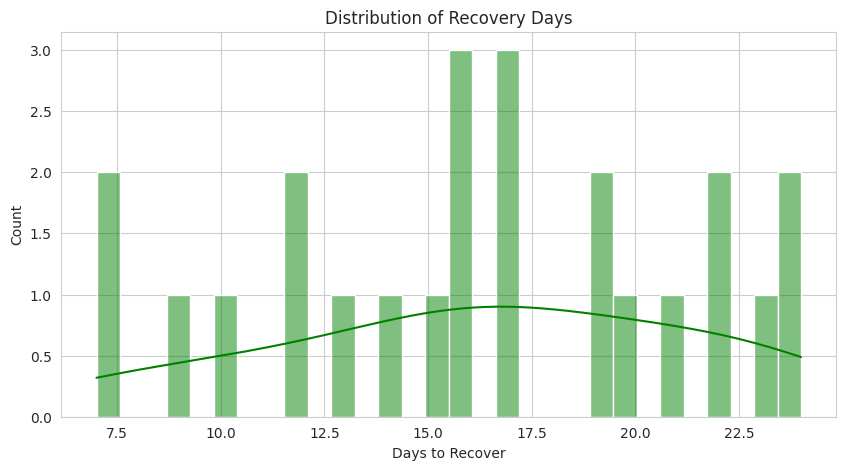

------------------------------
LINEAR REGRESSION RESULTS
------------------------------
Model Coefficients (Impact Factor):
  Age Effect: 0.0785
  Contact Number Effect: -0.0092

Model Performance:
  Mean Squared Error (MSE): 11.52
  R-Squared Score (R2): -0.6548
------------------------------

Interpretation:
- Older age is associated with longer recovery times.
- The R2 score of -0.6548 indicates how well Age and Contact Number explain the recovery time.


In [ ]:
# --- STEP 1: SETUP & DATA LOADING ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configure visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# DATA LOADING (Manual Upload Method)
# Ensure you have uploaded 'patient_data.csv' to the Colab Files section on the left
filename = 'patient_data.csv'

try:
    df = pd.read_csv(filename)
    print("✅ Data Loaded Successfully!")
except FileNotFoundError:
    print("❌ ERROR: File not found.")
    print("Please download the file from the Drive link, rename it to 'patient_data.csv',")
    print("and drag it into the Files folder on the left sidebar.")
    # Stop execution if file is missing
    raise

# --- STEP 2: DATA CLEANING & FEATURE ENGINEERING ---
# Convert date columns to datetime objects
date_cols = ['confirmed_date', 'released_date', 'deceased_date']
for col in date_cols:
    # Coerce errors to handle potential format mismatches
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Calculate Age (assuming 2020 as current year for this dataset context)
# Handling missing birth_year values by filling with median or dropping
df = df.dropna(subset=['birth_year'])
df['age'] = 2020 - df['birth_year']

# Calculate Recovery Duration (Target Variable)
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

# Filter for recovered cases only (where recovery_days is valid)
# We also remove negative values which might be data entry errors
recovered_df = df.dropna(subset=['recovery_days', 'age', 'contact_number'])
recovered_df = recovered_df[recovered_df['recovery_days'] >= 0]

print(f"Total Records: {len(df)}")
print(f"Recovered Cases for Analysis: {len(recovered_df)}\n")

# --- STEP 3: EXPLORATORY DATA ANALYSIS (EDA) ---
# Objective 1: Who is getting infected? (Demographics) [cite: 12]
plt.figure(figsize=(12, 5))

# Gender Distribution
plt.subplot(1, 2, 1)
sns.countplot(x='sex', data=df, palette='viridis')
plt.title('Distribution of Cases by Gender')

# Age Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['age'], bins=20, kde=True, color='blue')
plt.title('Distribution of Cases by Age')
plt.tight_layout()
plt.show()

# Objective 2: How are infections spreading? (Infection Reason) [cite: 13]
plt.figure(figsize=(12, 6))
# Filter top 10 reasons to avoid clutter
top_reasons = df['infection_reason'].value_counts().head(10).index
sns.countplot(y='infection_reason', data=df[df['infection_reason'].isin(top_reasons)],
              order=top_reasons, palette='magma')
plt.title('Top 10 Infection Sources')
plt.show()

# Objective 4: Which regions are most impacted? [cite: 19]
plt.figure(figsize=(12, 6))
top_regions = df['region'].value_counts().head(10).index
sns.countplot(y='region', data=df[df['region'].isin(top_regions)],
              order=top_regions, palette='coolwarm')
plt.title('Top 10 Most Impacted Regions')
plt.show()

# --- STEP 4: RECOVERY ANALYSIS & LINEAR REGRESSION ---
# Objective 3 & 5: Recovery Trends & Factors [cite: 17, 21]

# Visualization of Recovery Days
plt.figure(figsize=(10, 5))
sns.histplot(recovered_df['recovery_days'], bins=30, kde=True, color='green')
plt.title('Distribution of Recovery Days')
plt.xlabel('Days to Recover')
plt.show()

# Linear Regression Model [cite: 67]
# Features: Age, Contact Number
X = recovered_df[['age', 'contact_number']]
y = recovered_df['recovery_days']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation [cite: 69]
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print("LINEAR REGRESSION RESULTS")
print("-" * 30)
print(f"Model Coefficients (Impact Factor):")
print(f"  Age Effect: {model.coef_[0]:.4f}")
print(f"  Contact Number Effect: {model.coef_[1]:.4f}")
print(f"\nModel Performance:")
print(f"  Mean Squared Error (MSE): {mse:.2f}")
print(f"  R-Squared Score (R2): {r2:.4f}")
print("-" * 30)

# Interpretation
print("\nInterpretation:")
if model.coef_[0] > 0:
    print("- Older age is associated with longer recovery times.")
else:
    print("- Older age is associated with shorter recovery times.")
print(f"- The R2 score of {r2:.4f} indicates how well Age and Contact Number explain the recovery time.")